In [10]:
import numpy as np

# FFTs
def compute_fft(x):
    X = np.fft.fft(x)
    X = np.fft.fftshift(X)
    return 20 * np.log10(np.abs(X) + 1e-12)

# Parameters
N = 128
n = np.arange(N)

# Frequencies
k_aligned = 10          # perfectly aligned with FFT bin
k_misaligned = 10.5     # not aligned

# Signals
x_aligned = np.sin(2 * np.pi * k_aligned * n / N)
x_misaligned = np.sin(2 * np.pi * k_misaligned * n / N)

In [11]:
# Windows
rect_window = np.ones(N)
hann_window = np.hanning(N)

# FFT of windows
W_rect = compute_fft(rect_window)
W_hann = compute_fft(hann_window)

# Apply windows
x_misaligned_hann = x_misaligned * hann_window

In [12]:
X_aligned = compute_fft(x_aligned)
X_misaligned = compute_fft(x_misaligned)
X_misaligned_hann = compute_fft(x_misaligned_hann)
freq = np.linspace(-0.5, 0.5, N)

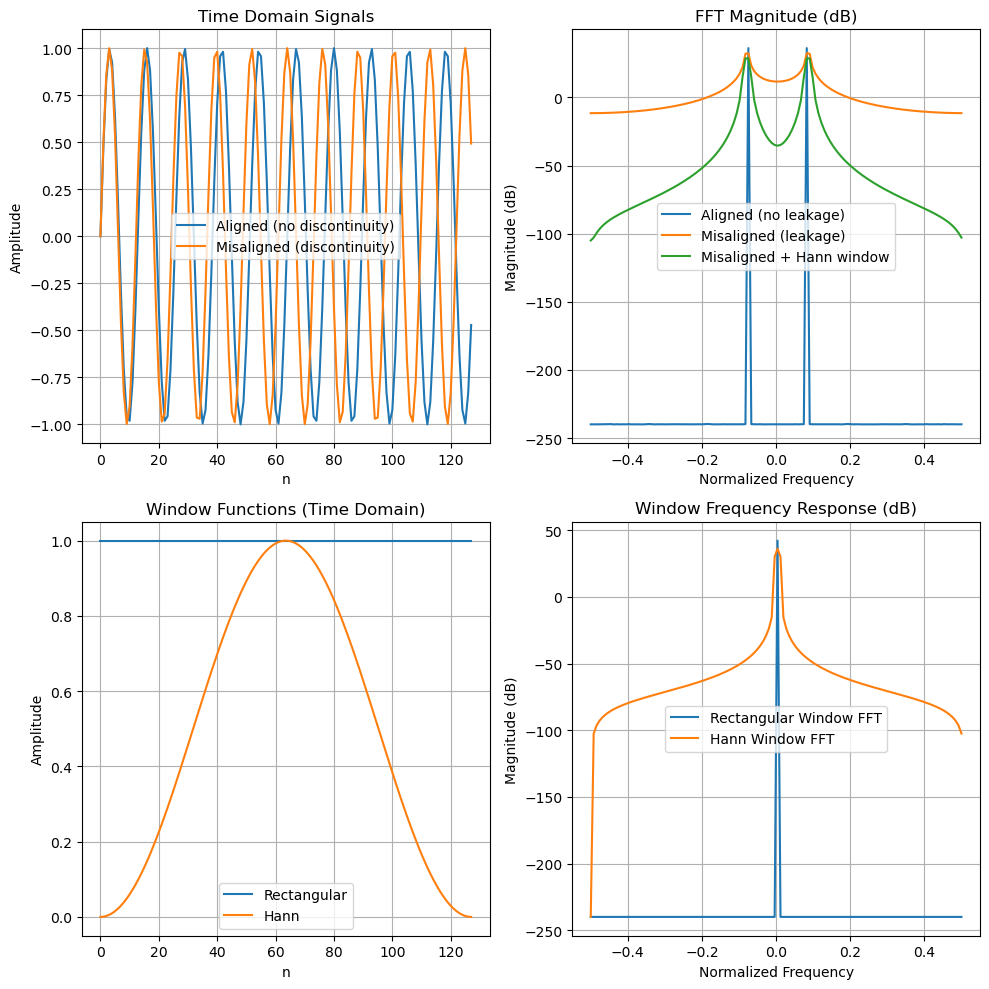

In [13]:
import matplotlib.pyplot as plt

fig,axes = plt.subplots(2,2, figsize=(10,10))

# =========================
# 1. Time-domain signals
# =========================
axes[0,0].plot(n, x_aligned, label="Aligned (no discontinuity)")
axes[0,0].plot(n, x_misaligned, label="Misaligned (discontinuity)")
axes[0,0].set_title("Time Domain Signals")
axes[0,0].set_xlabel("n")
axes[0,0].set_ylabel("Amplitude")
axes[0,0].legend()
axes[0,0].grid(True)

# =========================
# 2. FFT comparison
# =========================
axes[0,1].plot(freq, X_aligned, label="Aligned (no leakage)")
axes[0,1].plot(freq, X_misaligned, label="Misaligned (leakage)")
axes[0,1].plot(freq, X_misaligned_hann, label="Misaligned + Hann window")
axes[0,1].set_title("FFT Magnitude (dB)")
axes[0,1].set_xlabel("Normalized Frequency")
axes[0,1].set_ylabel("Magnitude (dB)")
axes[0,1].legend()
axes[0,1].grid(True)

# =========================
# 3. Window shapes (time)
# =========================
axes[1,0].plot(n, rect_window, label="Rectangular")
axes[1,0].plot(n, hann_window, label="Hann")
axes[1,0].set_title("Window Functions (Time Domain)")
axes[1,0].set_xlabel("n")
axes[1,0].set_ylabel("Amplitude")
axes[1,0].legend()
axes[1,0].grid(True)

# =========================
# 4. FFT of windows
# =========================
axes[1,1].plot(freq, W_rect, label="Rectangular Window FFT")
axes[1,1].plot(freq, W_hann, label="Hann Window FFT")
axes[1,1].set_title("Window Frequency Response (dB)")
axes[1,1].set_xlabel("Normalized Frequency")
axes[1,1].set_ylabel("Magnitude (dB)")
axes[1,1].legend()
axes[1,1].grid(True)

plt.tight_layout()
plt.show()